<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    Time Series Analysis and Forecasting-Solar generation and power demand
</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        About the Dataset: Italy Electricity Load & Solar Generation (2016)
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        The file <strong>timeseries_totalsolargen_and_load_it_2016.csv</strong> is a dataset available on Kaggle that contains hourly time series data regarding <strong>solar generation</strong> and <strong>total electricity consumption (load)</strong> in Italy during the year 2016.
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Data Details
    </p>

 <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>Resolution:</strong> Hourly.</li>
        <li><strong>Time Zone:</strong> Coordinated Universal Time (UTC).</li>
        <li><strong>Units:</strong> Power is expressed in Megawatts (MW).</li>
        <li><strong>Source:</strong> Data extracted from the "Open Power System Data" package, with primary data from the ENTSO-E Transparency platform.</li>
    </ul>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        File Structure
    </p>

  <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>Date and Time:</strong> Formatted as "%Y-%m-%dT%H%M%SZ".</li>
        <li><strong>Load:</strong> Total power demand in Italy.</li>
        <li><strong>Solar Generation:</strong> Total solar power generated across Italy's bidding zones (Nord, Centro Nord, etc.).</li>
    </ul>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        This dataset is commonly used in <strong>data science</strong> for <strong>energy forecasting</strong> and <strong>time series analysis</strong> exercises. You can download the dataset from the <a href="https://www.kaggle.com/" target="_blank">Kaggle website</a> to use it for analysis.
    </p>

</div>



https://www.kaggle.com/code/arielcedola/solar-generation-and-power-demand-in-italy/data


<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">3️⃣ Step 2 | Python Libraries </font><br>
 <br>   
<br>

In [1]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import itertools
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
from scipy import stats 




import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [3]:
df_1 = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\Solar generation and power demand\TimeSeries_TotalSolarGen_and_Load_IT_2016.csv')
df = df_1.copy() # fro heatmap and feature analysis

In [4]:
df.head()

,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01T00:00:00Z,21665.0,1
1,2016-01-01T01:00:00Z,20260.0,0
2,2016-01-01T02:00:00Z,19056.0,0
3,2016-01-01T03:00:00Z,18407.0,0
4,2016-01-01T04:00:00Z,18425.0,0


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [5]:
# info from of datasets
print(' shape of data set is = ',df.shape)
print()

print(' dataset head:\n')
df.head()
print()

print(' dataset info:\n')
dfinfo=df.info()
print()

print(' describtion of data set:\n')
df_des=df.describe().transpose()
df_des


 shape of data set is =  (8784, 3)

 dataset head:


 dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   utc_timestamp        8784 non-null   object 
 1   IT_load_new          8712 non-null   float64
 2   IT_solar_generation  8784 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB

 describtion of data set:



,count,mean,std,min,25%,50%,75%,max
IT_load_new,8712.0,32262.212236,7288.629858,16716.0,25909.5,31654.5,38685.75,48986.0
IT_solar_generation,8784.0,2049.831853,2845.846870,0.0,0.0,68.0,3923.50,15824.0


## Handle missing values

In [6]:
# Check for missing values
df.isnull().sum()

utc_timestamp           0
IT_load_new            72
IT_solar_generation     0
dtype: int64

In [7]:
# Fill missing values using forward fill
df['IT_load_new'].fillna(method='ffill', inplace=True)

# Check for missing values again
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
utc_timestamp          0
IT_load_new            0
IT_solar_generation    0
dtype: int64


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Distribution and anlaysis data
</center></p></h1>

# Distribution and analysing dataset

<Figure size 1280x960 with 0 Axes>

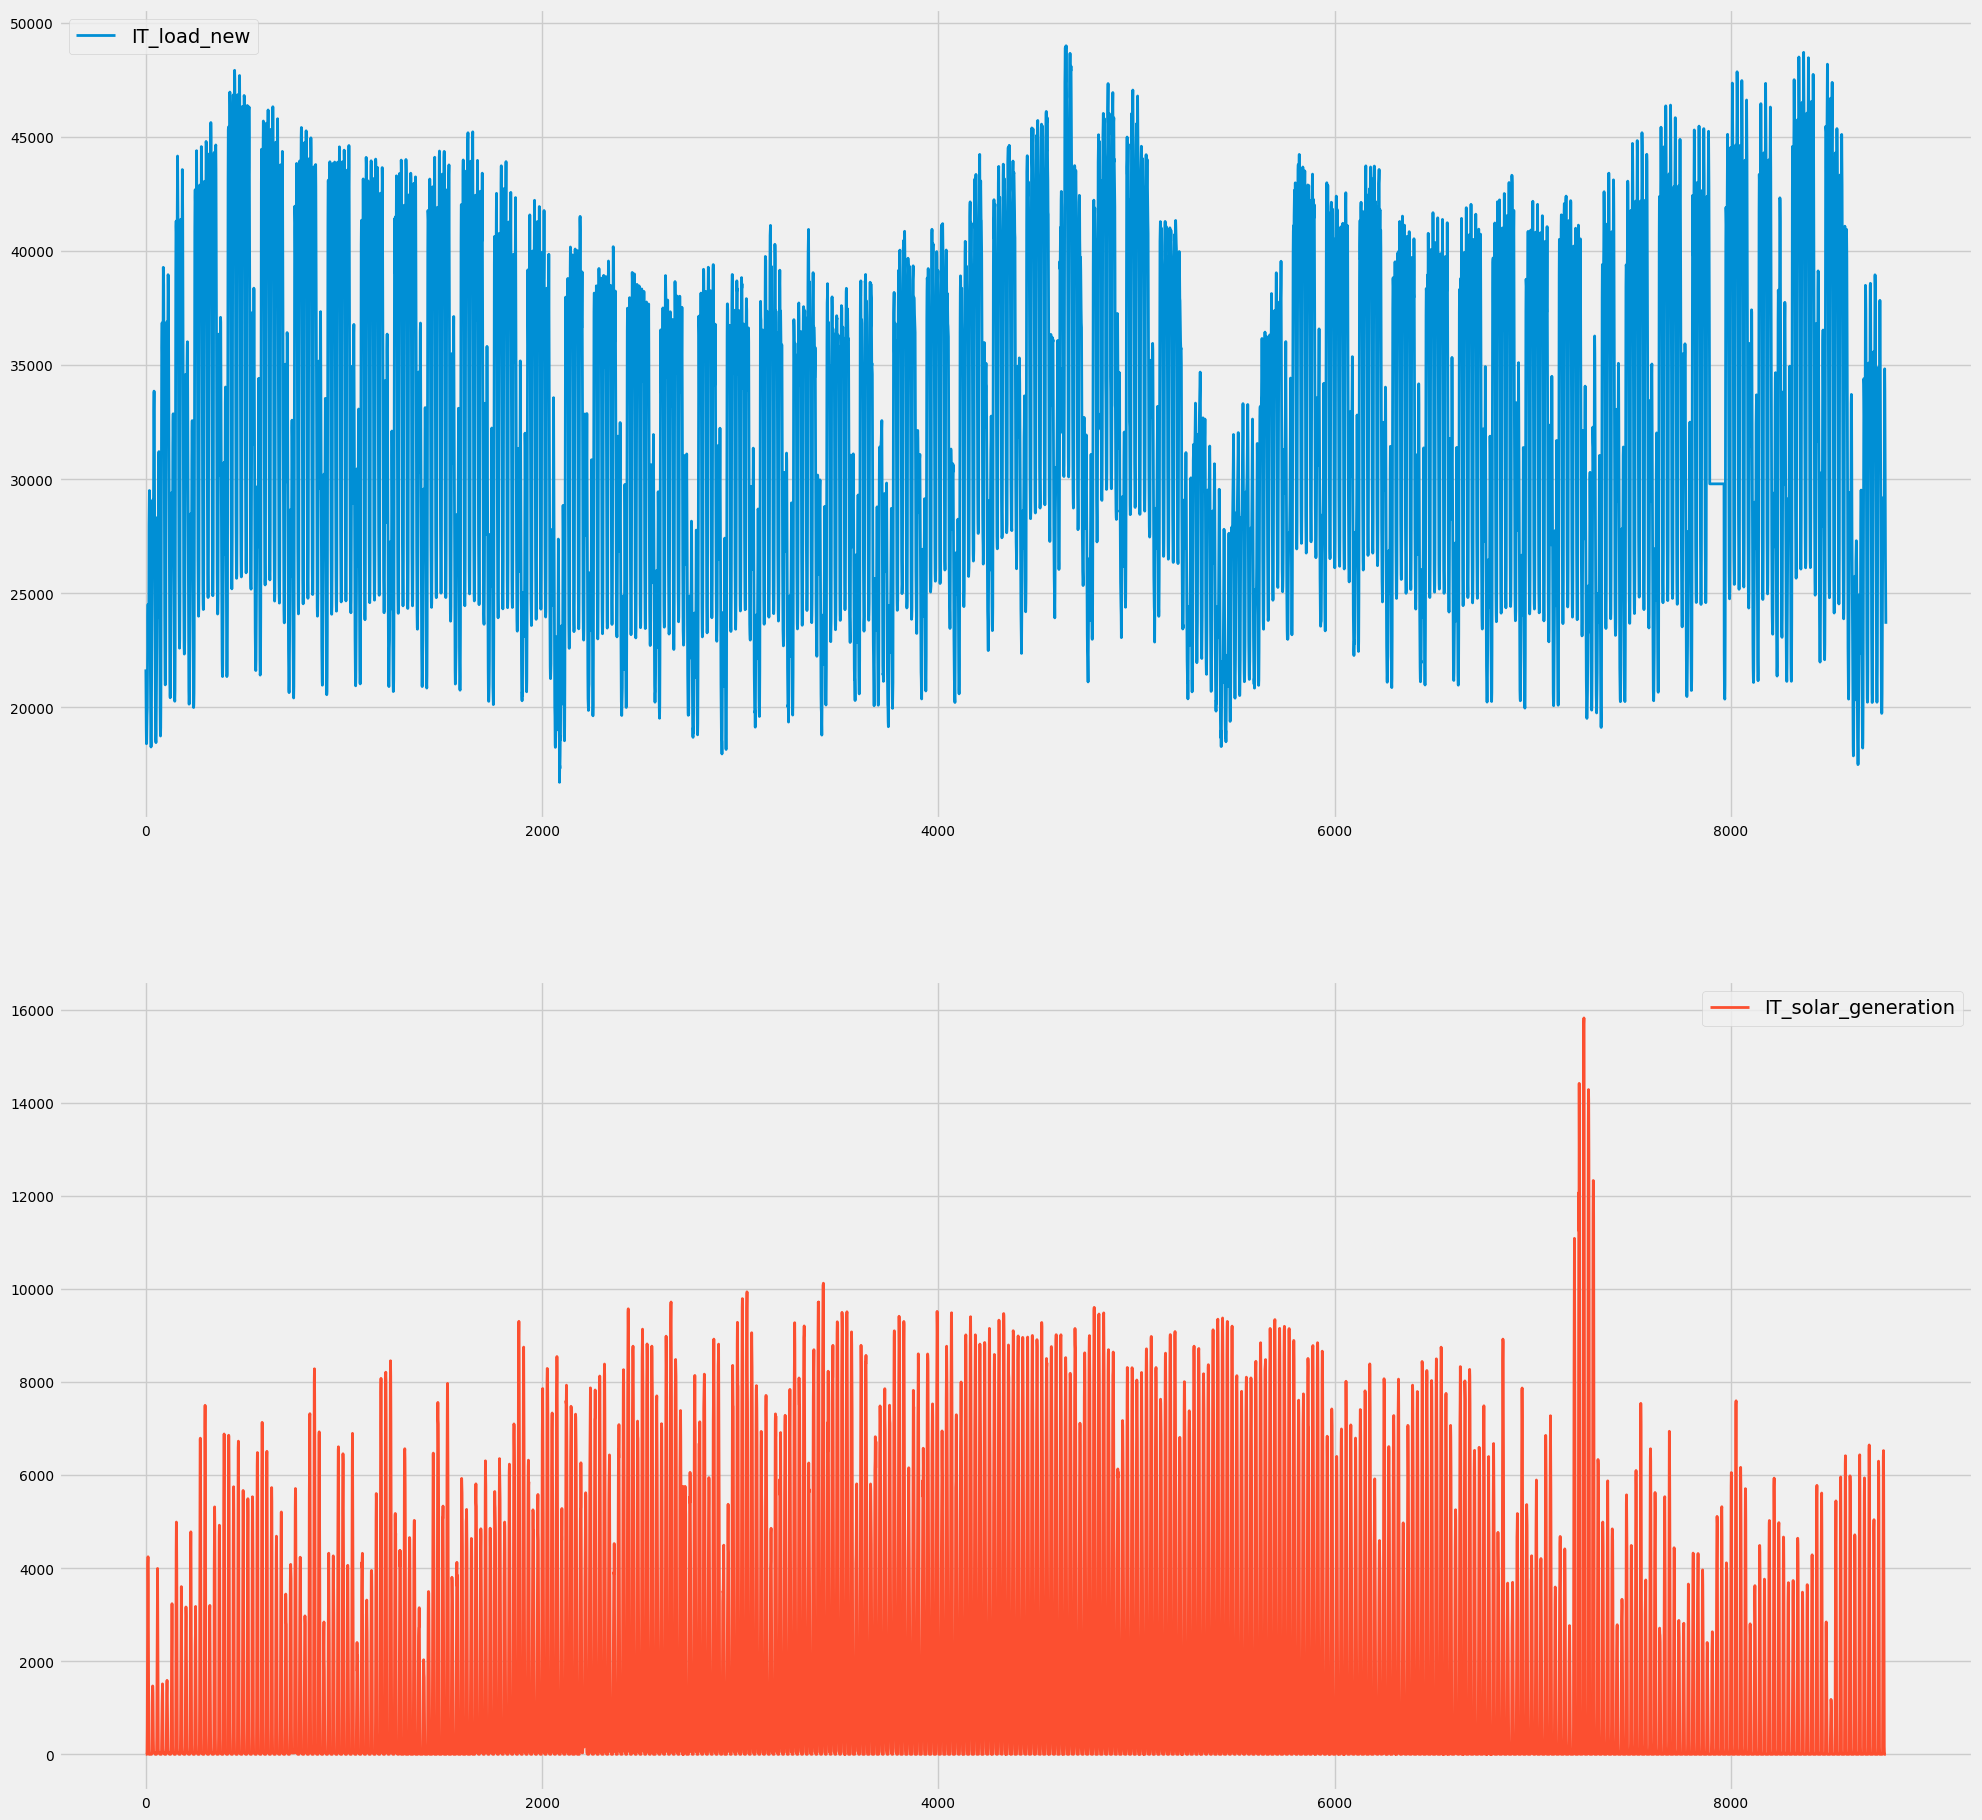

In [8]:
# Visualization of the primary dataset
plt.figure(dpi=200)
plt.style.use('fivethirtyeight')
df.plot(subplots=True, figsize=(22, 22), fontsize=10, linewidth=2, sharex=False)
plt.show()

<Figure size 1280x960 with 0 Axes>

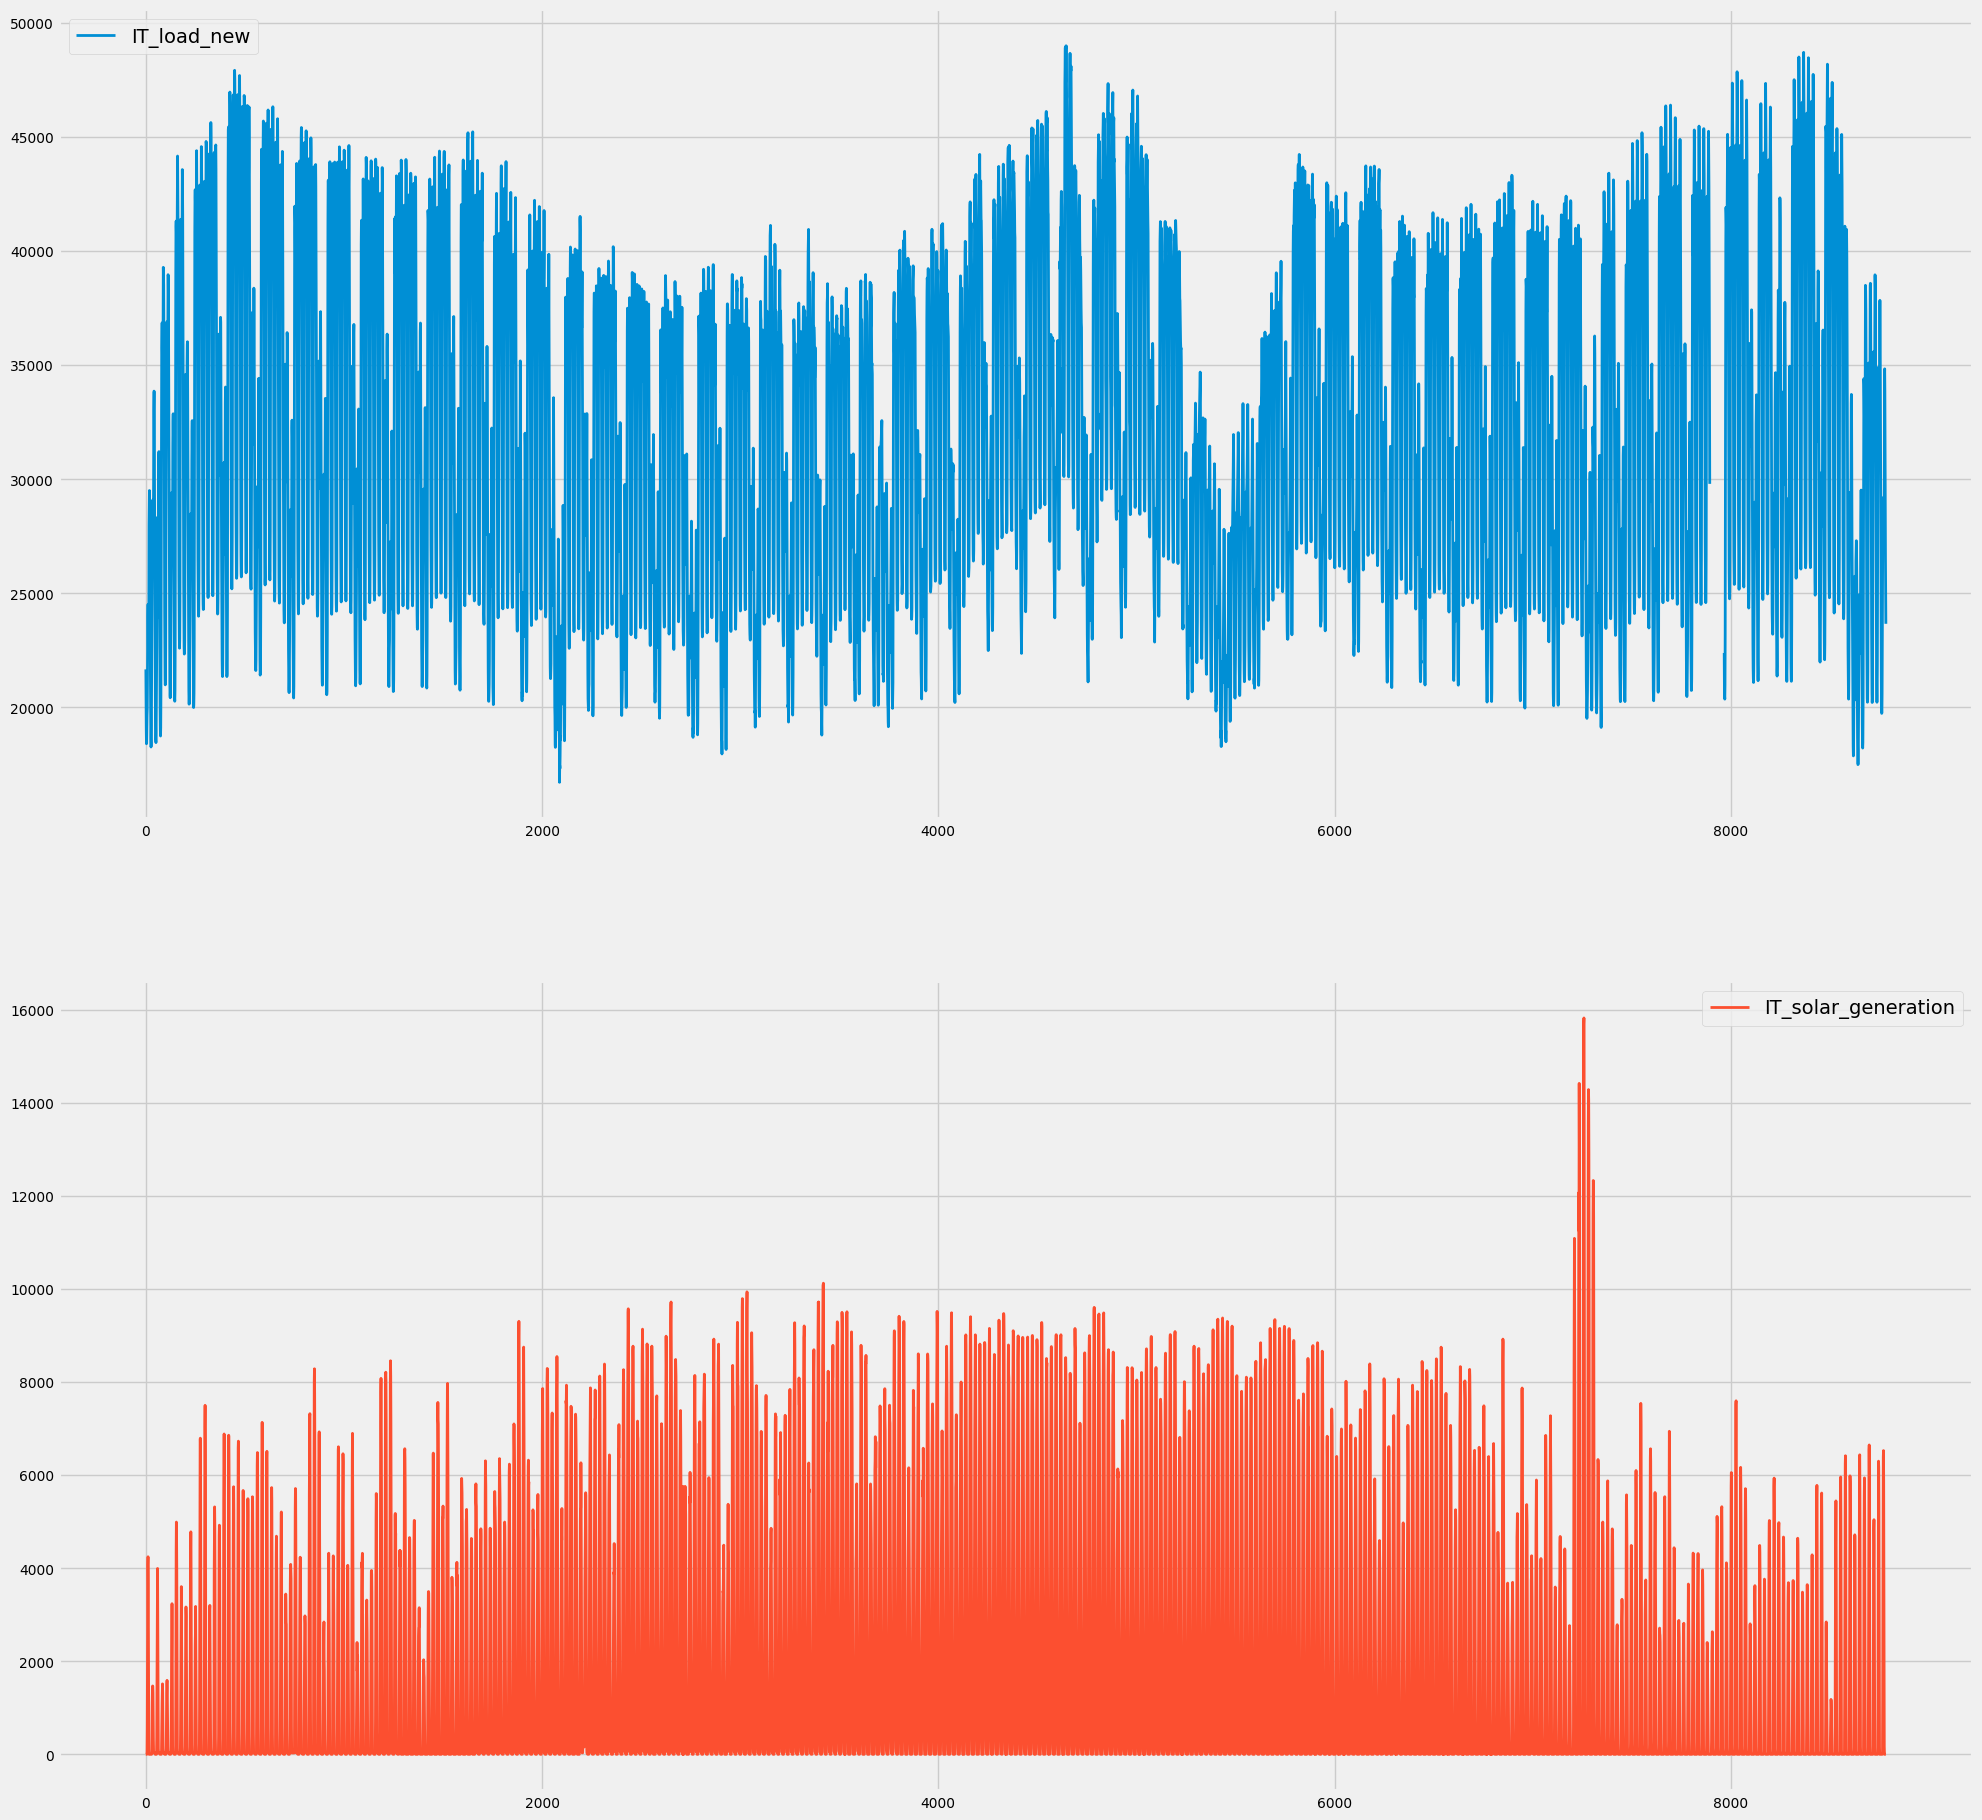

In [10]:
# Visualization of the primary dataset
df_col=['utc_timestamp', 'IT_load_new', 'IT_solar_generation']
plt.figure(dpi=200)
plt.style.use('fivethirtyeight')
df[df_col].plot(subplots=True, figsize=(22, 22), fontsize=10, linewidth=2, sharex=False)
plt.show()

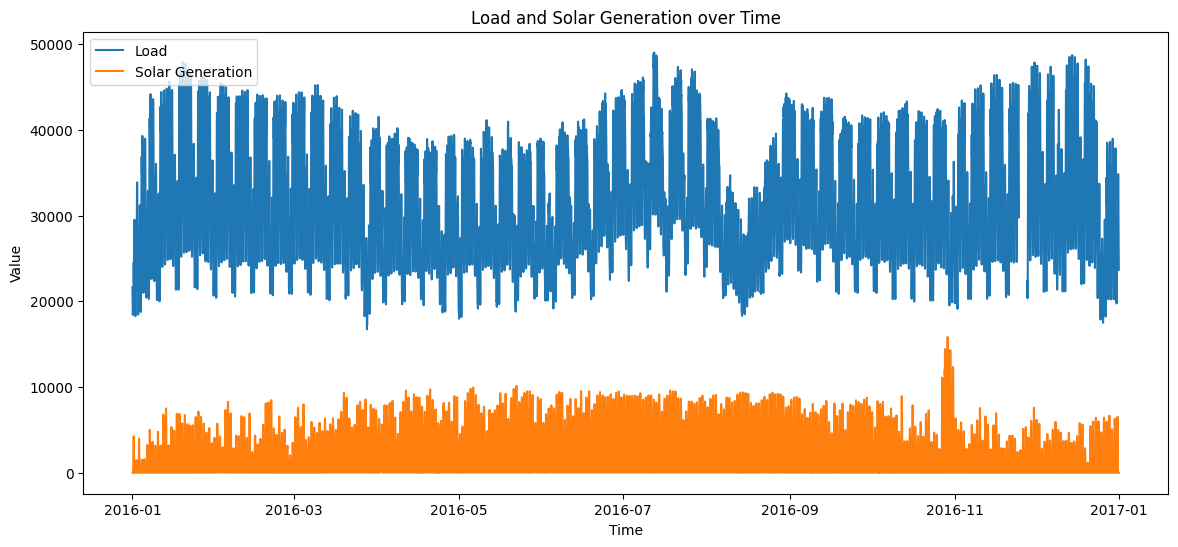

In [9]:
# Convert utc_timestamp to datetime
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Plot the data
plt.figure(figsize=(14,6))

plt.plot(df['utc_timestamp'], df['IT_load_new'], label='Load')
plt.plot(df['utc_timestamp'], df['IT_solar_generation'], label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Load and Solar Generation over Time')
plt.show()

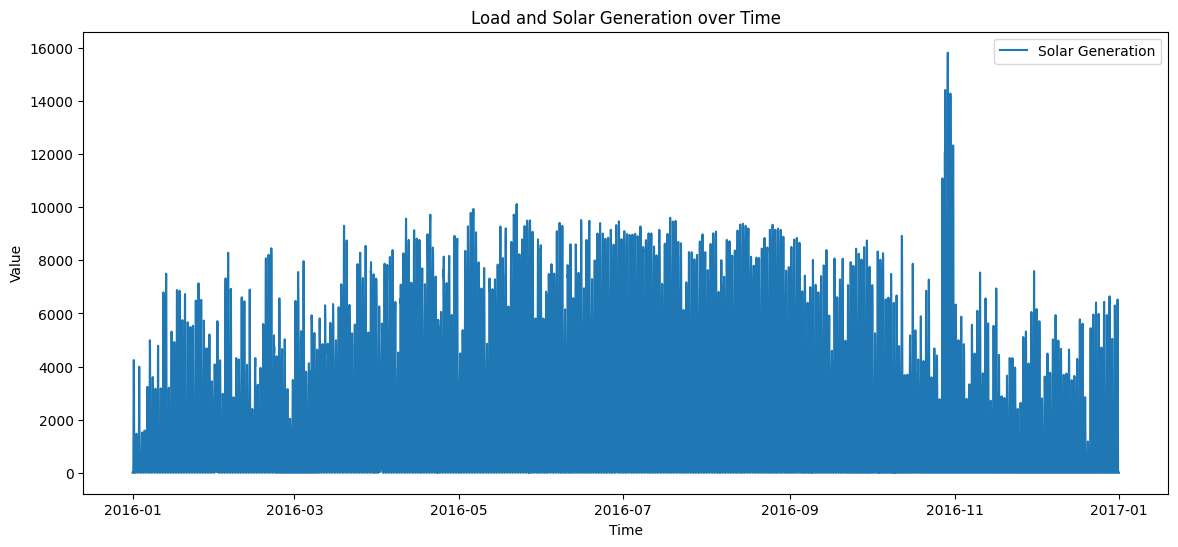

In [10]:
# Convert utc_timestamp to datetime
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Plot the data
plt.figure(figsize=(14,6))

#plt.plot(data['utc_timestamp'], data['IT_load_new'], label='Load')
plt.plot(df['utc_timestamp'], df['IT_solar_generation'], label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Load and Solar Generation over Time')
plt.show()

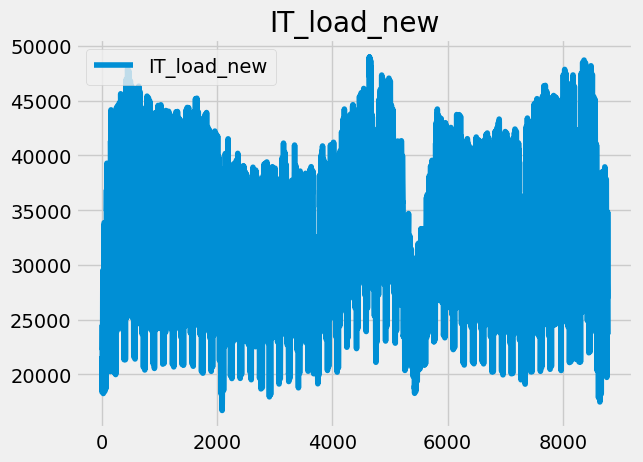

In [45]:
df[['IT_load_new']].plot(title='IT_load_new')
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Time Series Analysis: Load and Solar Generation (2016)
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        The plot shows both the <strong>load</strong> and <strong>solar generation</strong> over time for the year 2016. 
        The load appears to have a cyclical pattern with peaks and valleys, possibly corresponding to daily patterns of electricity use.
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        The solar generation also shows a clear pattern, with generation during the day and no generation at night, as expected. 
        The amount of solar generation also appears to fluctuate throughout the year, likely due to seasonal changes in sunlight.
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Importance of Stationarity
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Before moving on to time series analysis and forecasting with ARIMA, it's important to check for <strong>stationarity</strong> in your time series data. 
        Stationarity is a property of time series data that implies the mean, variance, and autocorrelation structure do not change over time. 
        Many time series models, including ARIMA, require the data to be stationary.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Let's perform an <strong>Augmented Dickey-Fuller (ADF) test</strong> to check the stationarity of the time series. 
        The null hypothesis of the ADF test is that the time series is non-stationary. 
        If the p-value of the test is less than the significance level (0.05), then you reject the null hypothesis 
        and infer that the time series is indeed stationary.
    </p>

</div>


<Figure size 1280x960 with 0 Axes>

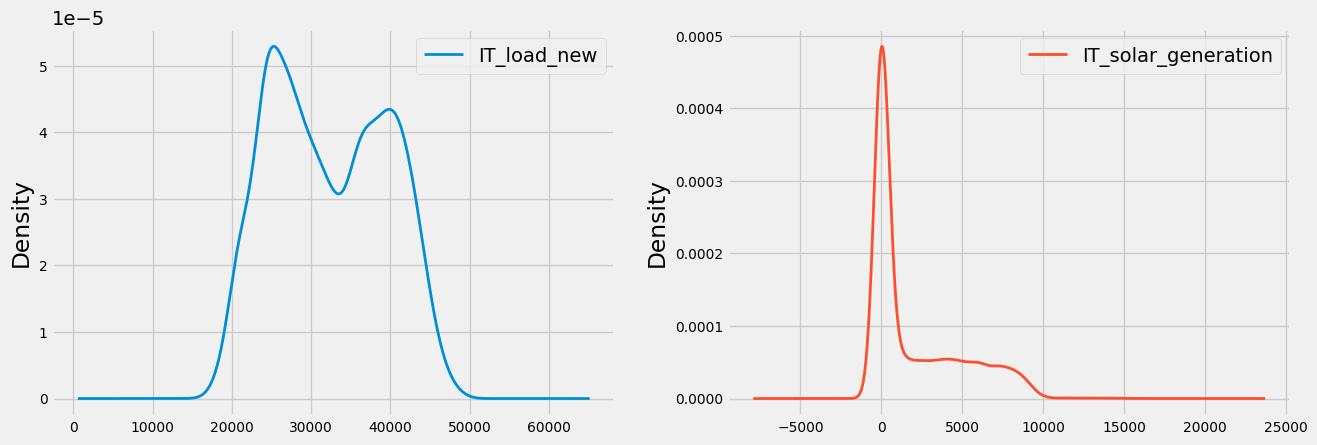

In [11]:
#disribution of the primary dataset
plt.figure(dpi=200)
df[df_col].plot(kind='density',subplots=True,layout=(4, 3), figsize=(22,22),
           fontsize=10, linewidth=2, sharex=False);
plt.show()

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Check for stationarity by Adfuller
</center></p></h1>



## 🎯 Key Insights
- Time series needs to be **stationary** before ARIMA modeling.  
- **AIC optimization** helps in selecting the best model parameters.  
- ARIMA provides solid results for datasets with **trend and seasonality**. 



In [15]:
# Function to perform Augmented Dickey-Fuller test
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [16]:
# Perform Augmented Dickey-Fuller test again
print("\nADF test for 'IT_load_new' after filling missing values:")
adf_test(df['IT_load_new'])

print("\nADF test for 'IT_solar_generation':")
adf_test(df['IT_solar_generation'])


ADF test for 'IT_load_new' after filling missing values:
Results of Dickey-Fuller Test:
Test Statistic                -1.197390e+01
p-value                        3.841445e-22
#Lags Used                     3.700000e+01
Number of Observations Used    8.746000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861871e+00
Critical Value (10%)          -2.566946e+00
dtype: float64

ADF test for 'IT_solar_generation':
Results of Dickey-Fuller Test:
Test Statistic                -5.741335e+00
p-value                        6.265438e-07
#Lags Used                     3.600000e+01
Number of Observations Used    8.747000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861870e+00
Critical Value (10%)          -2.566946e+00
dtype: float64


<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

   <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Augmented Dickey-Fuller Test Results
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        For <strong>'IT_load_new'</strong>: The p-value is extremely small (much less than 0.05), so we reject the null hypothesis 
        that the time series is non-stationary. Therefore, <strong>'IT_load_new'</strong> can be considered stationary.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        For <strong>'IT_solar_generation'</strong>: The p-value is also very small (much less than 0.05), so we reject the null hypothesis. 
        This means <strong>'IT_solar_generation'</strong> can be considered stationary as well.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Proceeding with ARIMA Modeling
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Since both series are stationary, we can proceed with building an <strong>ARIMA model</strong> for each of them.
    </p>

<p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        ARIMA stands for <strong>AutoRegressive Integrated Moving Average</strong>. It explains a given time series 
        based on its own past values (lags) and lagged forecast errors. This model can be used to forecast future values.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Any non-seasonal time series that exhibits patterns and is not random white noise can be modeled with ARIMA.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        An ARIMA model is characterized by three terms: <strong>p, d, q</strong>:
        <ul>
            <li><strong>p</strong>: Order of the AR term (number of lags of Y to be used as predictors).</li>
            <li><strong>d</strong>: Number of differencing required to make the series stationary.</li>
            <li><strong>q</strong>: Order of the MA term (moving average).</li>
        </ul>
        In our case, since the series are already stationary, <strong>d = 0</strong> for both series. 
        We need to determine the optimal values for <strong>p</strong> and <strong>q</strong> using the 
        <strong>ACF (Autocorrelation Function)</strong> and <strong>PACF (Partial Autocorrelation Function)</strong> plots.
    </p>

</div>


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Method for stationarity
</center></p></h1>

In [9]:
#رایج‌ترین روش برای از بین بردن Trend یا گرادیان خطی

data_diff = df['IT_load_new'].diff().dropna()
data_diff

1      -1405.0
2      -1204.0
3       -649.0
4         18.0
5        836.0
         ...  
8779   -2701.0
8780   -2812.0
8781   -1846.0
8782   -1220.0
8783   -1613.0
Name: IT_load_new, Length: 8783, dtype: float64

In [33]:
for col in df.select_dtypes(include=["number"]).columns:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"{col} - Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f}")

IT_load_new - Skewness: 0.11, Kurtosis: -1.16
IT_solar_generation - Skewness: 1.19, Kurtosis: 0.22


In [10]:
# --- 3) انتخاب سری مورد نظر برای مدل (مثلاً Load) ---
series = df['IT_load_new']  # یا هر ستون مد نظرت

# --- 4) تقسیم Train/Test 80/20 ---
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]
print("Train length:", len(train), "Test length:", len(test))

Train length: 7027 Test length: 1757


In [11]:
print(train.dtype)
print(train.head())
print(type(train))

float64
0    21665.0
1    20260.0
2    19056.0
3    18407.0
4    18425.0
Name: IT_load_new, dtype: float64
<class 'pandas.core.series.Series'>


In [20]:
train


,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01T00:00:00Z,21665.0,1
1,2016-01-01T01:00:00Z,20260.0,0
2,2016-01-01T02:00:00Z,19056.0,0
3,2016-01-01T03:00:00Z,18407.0,0
4,2016-01-01T04:00:00Z,18425.0,0
...,...,...,...
8755,2016-12-30T19:00:00Z,35074.0,0
8756,2016-12-30T20:00:00Z,32522.0,0
8757,2016-12-30T21:00:00Z,29523.0,0
8758,2016-12-30T22:00:00Z,26291.0,0


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Models</p>
</div>

# ================================
# SimpleExpSmoothing

# ================================

In [15]:
# ------------ 2) Fit SES Model ----------------
alpha = 0.2   # مقدار ساده آلفا
model = SimpleExpSmoothing(train).fit(smoothing_level=alpha)

# ------------ 3) Forecast ---------------------
y_pred = model.forecast(24)

# ------------ 4) Evaluation -------------------
mae = mean_absolute_error(test, y_pred)
print("MAE =", mae)

MAE = 5453.815348082065


In [16]:
# Align forecast index with test
y_pred = pd.Series(y_pred.values, index=test.index)
y_pred

7027    39363.297363
7028    39363.297363
7029    39363.297363
7030    39363.297363
7031    39363.297363
7032    39363.297363
7033    39363.297363
7034    39363.297363
7035    39363.297363
7036    39363.297363
7037    39363.297363
7038    39363.297363
7039    39363.297363
7040    39363.297363
7041    39363.297363
7042    39363.297363
7043    39363.297363
7044    39363.297363
7045    39363.297363
7046    39363.297363
7047    39363.297363
7048    39363.297363
7049    39363.297363
7050    39363.297363
dtype: float64

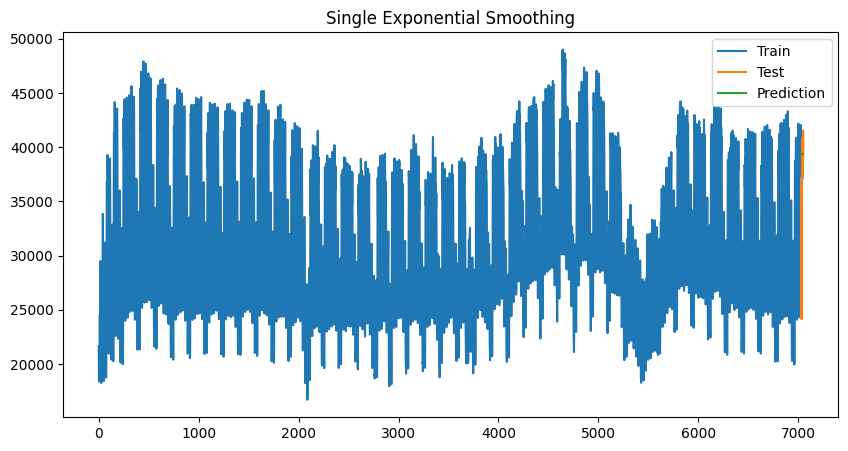

In [17]:
# ------------ 5) Plot -------------------------
plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(y_pred, label="Prediction")
plt.legend()
plt.title("Single Exponential Smoothing")
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Grid Search for SES</p>
</div>

In [47]:
# ---------------- SES ----------------
ses_alphas = np.arange(0.1, 1.0, 0.1)
best_ses = None
best_ses_score = float("inf")

for alpha in ses_alphas:
    model = SimpleExpSmoothing(train).fit(smoothing_level=alpha, optimized=False)
    pred = model.forecast(len(test))
    score = mean_squared_error(test, pred)
    if score < best_ses_score:
        best_ses_score = score
        best_ses = {'model': model, 'alpha': alpha, 'forecast': pred}


In [48]:
best_ses 

{'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x21df24ca1e0>,
 'alpha': 0.1,
 'forecast': 7027    37614.728261
 7028    37614.728261
 7029    37614.728261
 7030    37614.728261
 7031    37614.728261
 7032    37614.728261
 7033    37614.728261
 7034    37614.728261
 7035    37614.728261
 7036    37614.728261
 7037    37614.728261
 7038    37614.728261
 7039    37614.728261
 7040    37614.728261
 7041    37614.728261
 7042    37614.728261
 7043    37614.728261
 7044    37614.728261
 7045    37614.728261
 7046    37614.728261
 7047    37614.728261
 7048    37614.728261
 7049    37614.728261
 7050    37614.728261
 dtype: float64}

# ================================
# ARIMA

# ================================


In [14]:



# Fit the ARIMA model
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

# Make predictions on the test set
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, predictions))
rmse

7714.952134839938

In [16]:
# Fit the ARIMA model
model2 = ARIMA(train, order=(2,1,2))
model_fit2 = model2.fit()

# Make predictions on the test set
predictions2 = model_fit2.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse2 = np.sqrt(mean_squared_error(test, predictions))
rmse2

7714.952134839938

In [30]:
# Fit the ARIMA model
model3 = ARIMA(train, order=(2,2,2))
model_fit3 = model2.fit()

# Make predictions on the test set
predictions3 = model_fit3.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse3 = sqrt(mean_squared_error(test, predictions3))
rmse3

7993.849410767675

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 15px; background:#F2FFFF;">

 <p style="font-size: 16px; color: green; font-weight: bold; text-align:center;">
        📊 Evaluation of ARIMA Model Performance on IT_load_new
    </p>

 <p style="text-align: justify;">
        The <strong>Root Mean Squared Error (RMSE)</strong> for the ARIMA model on <strong>'IT_load_new'</strong> is approximately 
        <span style="color:red; font-weight:bold;">7715</span>. RMSE measures the differences between the values predicted by the model and the values actually observed. 
        It is a widely used metric to evaluate how accurately a model predicts the response and is considered one of the most important criteria if the main goal is prediction.
    </p>

 <p style="color:green; font-weight:bold;">📌 Important Notes</p>
    <ul>
        <li>The RMSE value itself is not very informative without a benchmark.</li>
        <li>Compare RMSE to the standard deviation of the actual values to see if the model error is acceptable.</li>
        <li>Compare RMSE between different models on the same dataset (e.g., ARIMA, SARIMAX, Prophet, LSTM) to identify the best model.</li>
    </ul>

 <p style="color:green; font-weight:bold;">📈 Visual Comparison</p>
    <p>
        One of the best ways to assess the model's performance is by plotting the actual vs forecasted values. 
        This allows us to see how closely the model predictions follow the real data.
    </p>

 <div style="text-align:center; padding:10px;">
        <img src="YOUR_PLOT_IMAGE.png" style="width:90%; border-radius:10px; border:2px solid #008000;">
        <p style="font-size:12px; color:#555;">(Replace this image with your actual vs predicted plot)</p>
    </div>

 <p style="color:green; font-weight:bold;">📌 Conclusion</p>
    <p>
        The ARIMA model captures the overall trend of the 'IT_load_new' series reasonably well. 
        To improve accuracy, consider using more advanced models such as <strong>SARIMAX</strong> for seasonal effects, 
        <strong>Prophet</strong> for trend and seasonality, or <strong>LSTM</strong> for complex non-linear patterns. 
        Comparing these models using RMSE and visual inspection will help select the most reliable forecasting approach.
    </p>

</div>


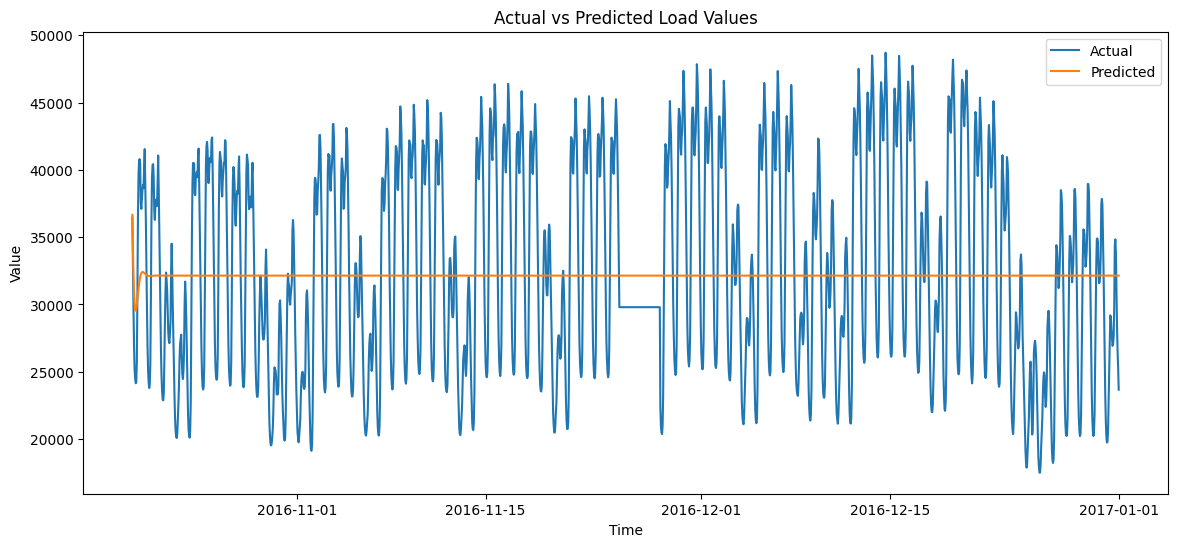

In [31]:
# Plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(df['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Actual vs Predicted Load Values')
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 15px; background:#F2FFFF;">

  <p style="font-size: 16px; color: green; font-weight: bold; text-align:center;">
        📊 ARIMA Model Performance: IT_load_new vs Test Set
    </p>

<p>
        The plot shows the <strong>actual versus predicted load values</strong> for the test set. 
        The ARIMA model is able to capture the general pattern and structure of the time series data. 
        However, some differences between the actual and predicted values still remain.
    </p>

 <p style="color:green; font-weight:bold;">📌 Possible Reasons for Discrepancies</p>
    <ul>
        <li>Inherent randomness in the electricity load data.</li>
        <li>Other external factors that are not included in the model.</li>
        <li>Limitations of the ARIMA model itself, which assumes linear relationships.</li>
    </ul>

 <p>
        More complex models or additional data preprocessing steps could potentially improve the prediction results.
    </p>

 <p style="color:green; font-weight:bold;">📈 Next Steps: IT_solar_generation</p>
    <p>
        We will repeat the same forecasting process for the <strong>'IT_solar_generation'</strong> time series. 
        The first step is to plot the <strong>ACF (Autocorrelation Function)</strong> and <strong>PACF (Partial Autocorrelation Function)</strong> 
        to help determine the optimal parameters (p, d, q) for the ARIMA model.
    </p>





<div style="text-align:center; padding:10px;">
        <img src="YOUR_PLOT_IMAGE.png" style="width:90%; border-radius:10px; border:2px solid #008000;">
        <p style="font-size:12px; color:#555;">(Replace this image with the actual vs predicted plot for IT_load_new)</p>
    </div>

</div>


In [33]:
# Split the data into training and test sets
train_size = int(len(df['IT_solar_generation']) * 0.8)
train, test = df['IT_solar_generation'][:train_size], df['IT_solar_generation'][train_size:]

# Fit the ARIMA model
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

# Make predictions on the test set
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, predictions))
rmse

2486.1507110856382

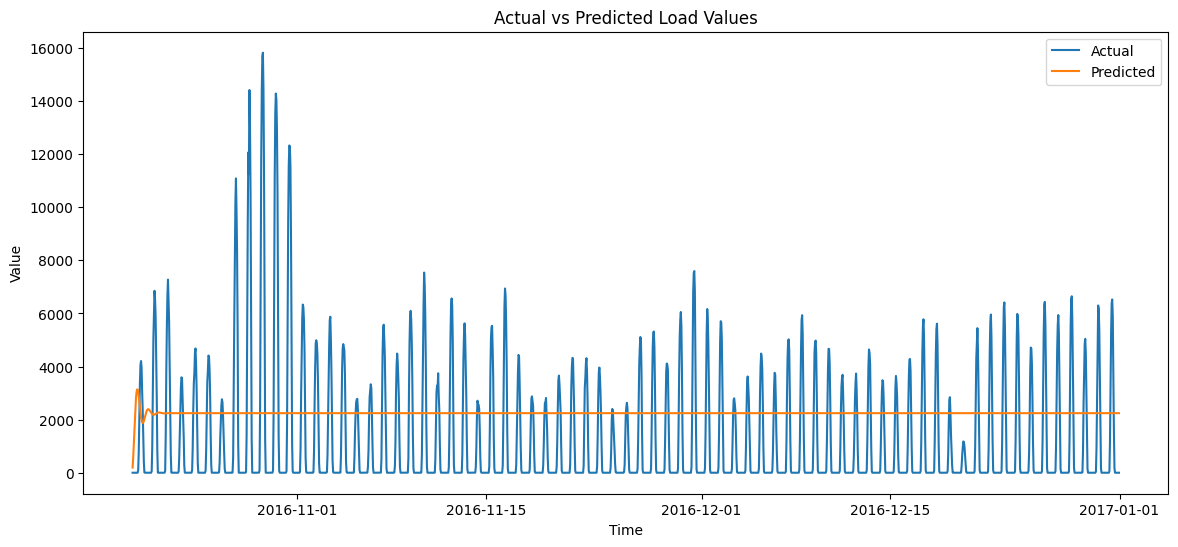

In [34]:
# Plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(df['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Actual vs Predicted Load Values')
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 15px; background:#F2FFFF;">

  <p style="font-size: 16px; color: green; font-weight: bold; text-align:center;">
        📊 ARIMA Model Performance: IT_solar_generation
    </p>

  <p>
        The <strong>Root Mean Squared Error (RMSE)</strong> for the ARIMA model on <strong>'IT_solar_generation'</strong> is approximately 
        <span style="color:red; font-weight:bold;">2486</span>. As with the 'IT_load_new' model, this RMSE value indicates how accurately the model predicts the response.
    </p>

  <p style="color:green; font-weight:bold;">📌 Interpretation</p>
    <ul>
        <li>The RMSE shows the average deviation between predicted and actual solar generation values.</li>
        <li>A lower RMSE indicates better prediction accuracy, but it is always useful to compare it with the data scale or other models.</li>
        <li>Visual inspection is also crucial to understand how well the model captures trends and patterns.</li>
    </ul>

  <p style="color:green; font-weight:bold;">📈 Visual Comparison</p>
    <p>
        The plot below shows the <strong>actual versus predicted solar generation</strong> values for the test set. 
        Similar to the load model, the ARIMA model captures the general pattern of the time series data, although some differences remain.
    </p>

 <div style="text-align:center; padding:10px;">
        <img src="YOUR_SOLAR_PLOT_IMAGE.png" style="width:90%; border-radius:10px; border:2px solid #008000;">
        <p style="font-size:12px; color:#555;">(Replace this image with your actual vs predicted plot for IT_solar_generation)</p>
    </div>

</div>


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> ACF & PACF Plots</p>
</div>

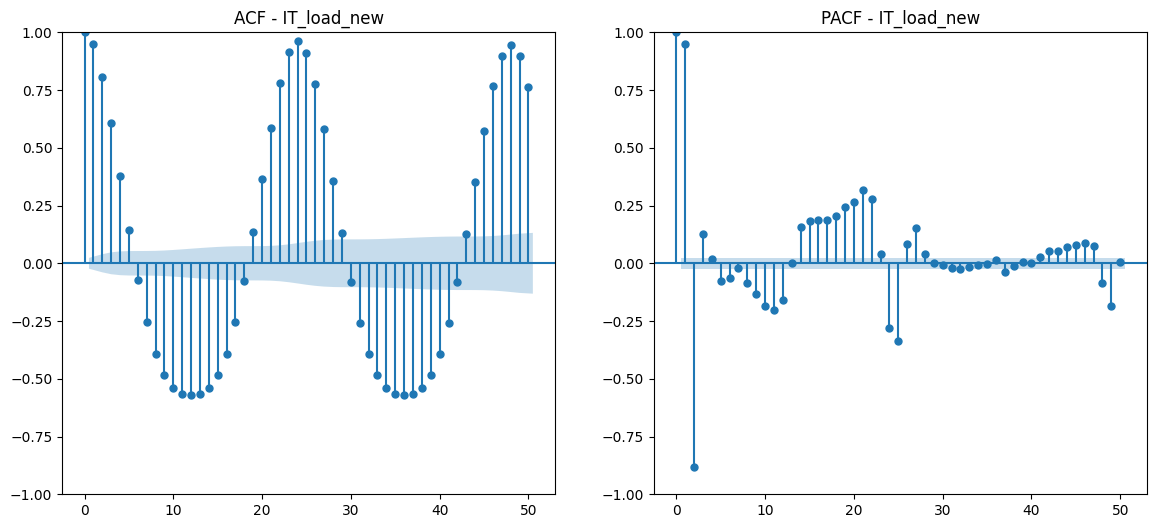

In [38]:


# Plot ACF and PACF for IT_load_new
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plot_acf(train, lags=50, ax=plt.gca())
plt.title("ACF - IT_load_new")

plt.subplot(1,2,2)
plot_pacf(train, lags=50, ax=plt.gca())
plt.title("PACF - IT_load_new")

plt.show()


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> auto_arima </p>
</div>

In [ ]:
# ------------------------

auto_model =auto_arima(train,
                           start_p=0, start_q=0,
                           max_p=5, max_q=5,
                           seasonal=False,   
                           d=None,          
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True,
                           information_criterion='aic')

print("Auto ARIMA summary:")
print(auto_model.summary())

# 
best_order = auto_model.order
print("Best order (p,d,q):", best_order)

model_arima = ARIMA(train, order=best_order)
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=116320.031, Time=0.32 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=108054.491, Time=0.43 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=110817.520, Time=2.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=116318.031, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=106900.481, Time=0.63 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=106628.955, Time=0.83 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=106581.052, Time=0.86 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=106519.111, Time=1.30 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=14.02 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=10.83 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AIC=106517.112, Time=0.70 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=106579.052, Time=0.52 sec
 ARIMA(5,1,1)(0,0,0)[0]             : AIC=inf, Time=9.94 sec
 ARIMA(4,1,1)(0,0,0)[0]             : AIC=inf, Time=9.00 sec

Best model:  ARIMA(5,1,0)(0,0,

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Forecast 30 days ahead </p>
</div>

In [ ]:
forecast_steps = 2160

forecast_3months = model_fit.forecast(steps=forecast_steps)


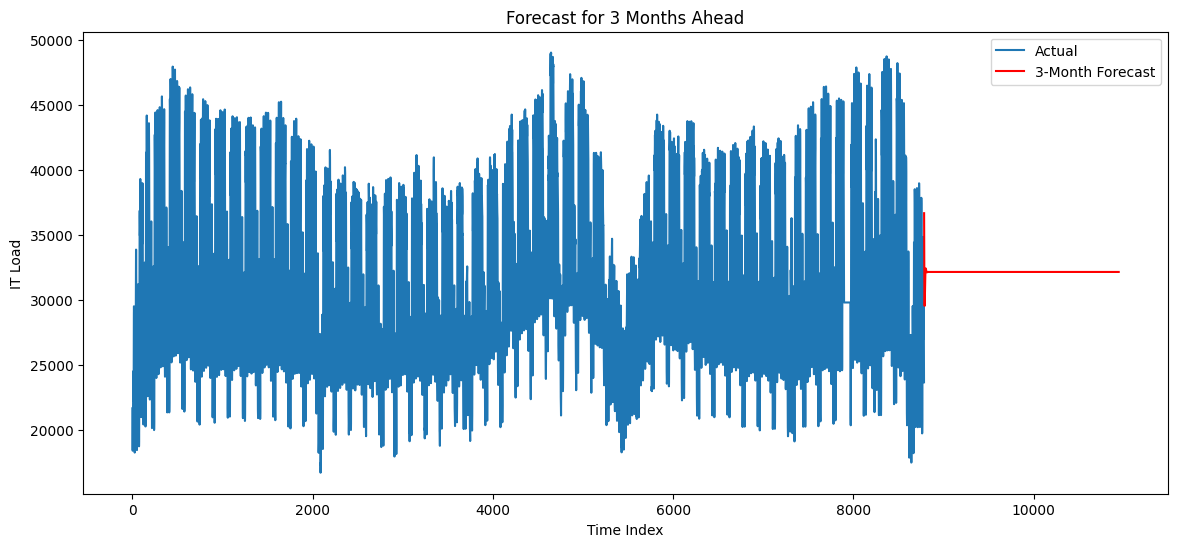

In [20]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['IT_load_new'], label='Actual')
plt.plot(range(len(df), len(df)+forecast_steps), forecast_3months, label='3-Month Forecast', color='red')
plt.xlabel('Time Index')
plt.ylabel('IT Load')
plt.legend()
plt.title('Forecast for 3 Months Ahead')
plt.show()

# ================================
# SARIMA

# ================================

In [21]:
def evaluate_series(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

In [22]:
# ------------------------
# 7) SARIMAX (for seasonal data) -- example with weekly seasonality (m=168)
# ------------------------
# اگر داده دارای فصل روزانه یا هفتگی باشه، seasonal_order=(P,D,Q,m)
m = 24   # daily seasonality for hourly data; or 168 for weekly
# برای انتخاب بهترین seasonal order می‌تونی grid search ساده انجام بدی؛ در اینجا یک نمونه SARIMAX اجرا می‌کنیم:
# Manually chosen parameters
order = (1, 1, 1)               # p,d,q
seasonal_order = (1, 0, 1, 24)  # P,D,Q,m; m=24 for daily seasonality in hourly data

sarimax_model = SARIMAX(train,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarimax_res = sarimax_model.fit(disp=False)
print(sarimax_res.summary())



                                     SARIMAX Results                                      
Dep. Variable:                        IT_load_new   No. Observations:                 7027
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood              -55254.277
Date:                            Wed, 03 Dec 2025   AIC                         110518.555
Time:                                    00:57:52   BIC                         110552.823
Sample:                                         0   HQIC                        110530.363
                                           - 7027                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4973      0.014     35.100      0.000       0.470       0.525
ma.L1          0.1846      0.016   

In [26]:
start = test.index[0]
end = test.index[-1]



pred_sarimax = sarimax_res.predict(start=start, end=end)
evaluation = evaluate_series(test, pred_sarimax)
print("SARIMAX Evaluation:", evaluation)

SARIMAX Evaluation: {'MSE': 704301.2716801083, 'RMSE': 839.2265913804854, 'MAPE': 0.02380962925154628}


In [ ]:
# Non-seasonal (p,d,q) ranges
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

# Seasonal (P,D,Q,m) ranges
P = D = Q = range(0, 2)
m = 24  # daily seasonality for hourly data
seasonal_pdq = [(x[0], x[1], x[2], m) for x in itertools.product(P,D,Q)]

best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            model = SARIMAX(train,
                            order=param,
                            seasonal_order=seasonal_param,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = param
                best_seasonal_order = seasonal_param
                best_model = results
        except:
            continue

print("Best SARIMAX order:", best_order)
print("Best seasonal_order:", best_seasonal_order)
print("Best AIC:", best_aic)


In [ ]:
pred_sarimax = best_model.predict(start=start, end=end)
evaluation = evaluate_series(test, pred_sarimax)
print("SARIMAX evaluation:", evaluation)


In [ ]:
plt.figure(figsize=(14,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred_sarimax, label='SARIMAX Forecast')
plt.legend()
plt.title("SARIMAX Forecast vs Actual")
plt.show()


# ================================
# Prophet 
# ================================

In [ ]:

# Use your actual columns
prophet_df = df[['utc_timestamp', 'IT_load_new']].rename(columns={'utc_timestamp':'ds', 'IT_load_new':'y'})

# Ensure datetime format
prophet_df['ds'] = pd.to_datetime(prophet_df['ds']).dt.tz_localize(None)


train_size = int(len(prophet_df) * 0.8)
train_df = prophet_df.iloc[:train_size]
test_df = prophet_df.iloc[train_size:]



In [43]:
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
model.fit(train_df)

01:07:19 - cmdstanpy - INFO - Chain [1] start processing
01:07:23 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
future = model.make_future_dataframe(periods=len(test_df), freq='H')  # 'H' for hourly, 'D' for daily
forecast = model.predict(future)

# Extract test predictions
pred = forecast['yhat'][-len(test_df):].values

pred


array([39794.70848974, 37141.60428121, 33897.00366454, ...,
       26652.66132208, 23609.63670953, 21547.40481313])

In [46]:
def evaluate_series(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

evaluation = evaluate_series(test_df['y'].values, pred)
print("Prophet Evaluation:", evaluation)


Prophet Evaluation: {'MSE': 19060503.662224814, 'RMSE': 4365.833673220363, 'MAPE': 0.1146290837795853}


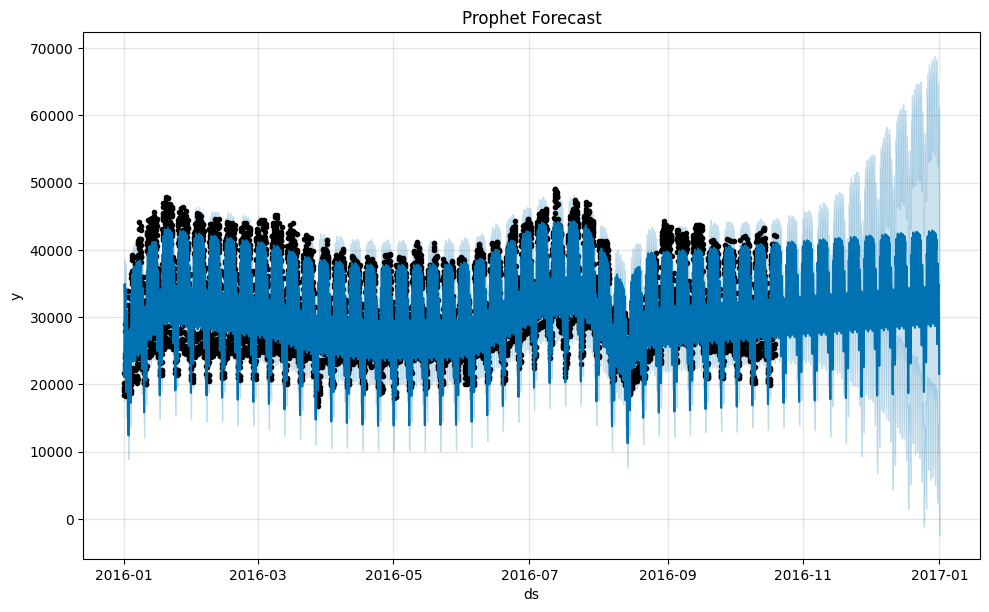

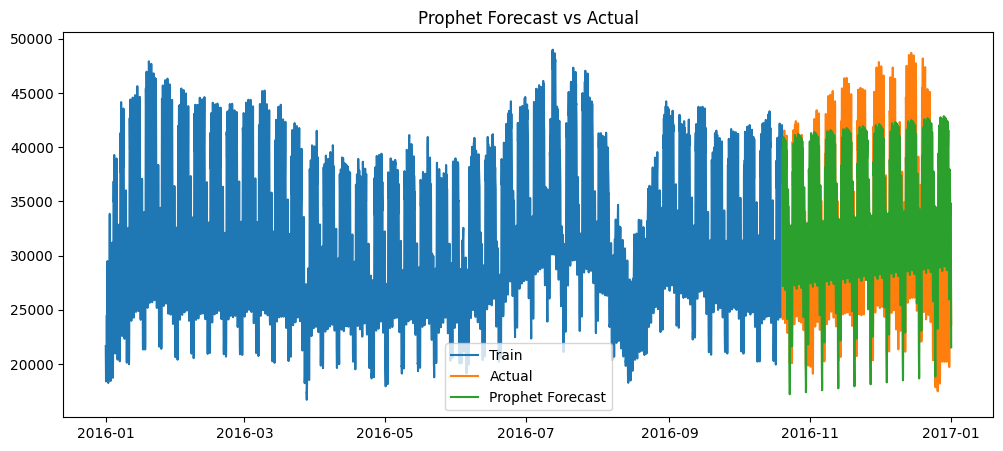

In [47]:
# Prophet's built-in plot
model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

# Compare actual vs predicted
plt.figure(figsize=(12,5))
plt.plot(train_df['ds'], train_df['y'], label='Train')
plt.plot(test_df['ds'], test_df['y'], label='Actual')
plt.plot(test_df['ds'], pred, label='Prophet Forecast')
plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.show()
